In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#read the dataset
data1 = pd.read_csv('/content/drive/MyDrive/Fake_reviews/Yelp NYC Metadata.csv')
data2 = pd.read_csv('/content/drive/MyDrive/Fake_reviews/yelp.csv')

In [ ]:
#check the head of dataset
data1.head()

,Product_id,Product_id2,Rating,Label,Date
0,923,0,3,-1,12/8/2014
1,924,0,3,-1,5/16/2013
2,925,0,4,-1,7/1/2013
3,926,0,4,-1,7/28/2011
4,927,0,4,-1,11/1/2010


In [ ]:
data1['Label'].value_counts()

 1    322167
-1     36885
Name: Label, dtype: int64

In [ ]:
data2.head()

,Review_id,Product_id,Date,Review
0,923,0,12/8/2014,The food at snack is a selection of popular Gr...
1,924,0,5/16/2013,This little place in Soho is wonderful. I had ...
2,925,0,7/1/2013,ordered lunch for 15 from Snack last Friday. Â...
3,926,0,7/28/2011,This is a beautiful quaint little restaurant o...
4,927,0,11/1/2010,Snack is great place for a Â casual sit down l...


In [ ]:
#check the shape of the given dataset
print(f'first dataset has {data1.shape[0]} number of rows and {data1.shape[1]} number of columns')
print(f'second dataset has {data2.shape[0]} number of rows and {data2.shape[1]} number of columns')

first dataset has 359052 number of rows and 5 number of columns
second dataset has 359052 number of rows and 4 number of columns


In [ ]:
data= pd.DataFrame()
data['User_id'] = data2['Review_id']
data['Product_id'] = data2['Product_id']
data['Rating'] = data1['Rating']
data['Date'] = data1['Date']
data['Review'] =  data2['Review']
data['Label'] = data1['Label']
data.head()

,User_id,Product_id,Rating,Date,Review,Label
0,923,0,3,12/8/2014,The food at snack is a selection of popular Gr...,-1
1,924,0,3,5/16/2013,This little place in Soho is wonderful. I had ...,-1
2,925,0,4,7/1/2013,ordered lunch for 15 from Snack last Friday. Â...,-1
3,926,0,4,7/28/2011,This is a beautiful quaint little restaurant o...,-1
4,927,0,4,11/1/2010,Snack is great place for a Â casual sit down l...,-1


In [ ]:
import pandas as pd
# '-1' implies negative review and '+1' implies positive review
#  Replacing '-1' with '0' in the 'label' column for negative review
data['Label'] = data['Label'].replace(-1, 0)
data.head()

,User_id,Product_id,Rating,Date,Review,Label
0,923,0,3,12/8/2014,The food at snack is a selection of popular Gr...,0
1,924,0,3,5/16/2013,This little place in Soho is wonderful. I had ...,0
2,925,0,4,7/1/2013,ordered lunch for 15 from Snack last Friday. Â...,0
3,926,0,4,7/28/2011,This is a beautiful quaint little restaurant o...,0
4,927,0,4,11/1/2010,Snack is great place for a Â casual sit down l...,0


In [ ]:
data['Label'].value_counts()

1    322167
0     36885
Name: Label, dtype: int64

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359052 entries, 0 to 359051
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   User_id     359052 non-null  int64 
 1   Product_id  359052 non-null  int64 
 2   Rating      359052 non-null  int64 
 3   Date        359052 non-null  object
 4   Review      359052 non-null  object
 5   Label       359052 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 16.4+ MB


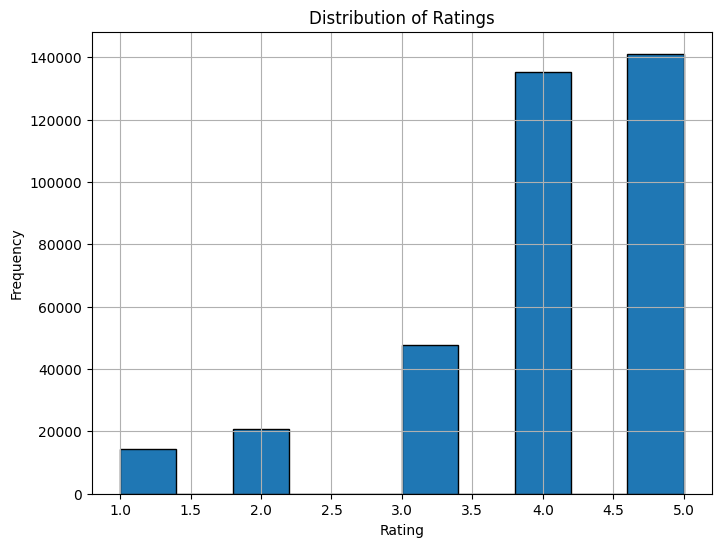

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(data['Rating'], bins=10, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings')
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(200, 100))
rating_counts = data.groupby('Product_id')['Rating'].count().sort_values(ascending=False)
rating_counts.plot(kind='bar')
plt.xlabel('Product ID')
plt.ylabel('Rating Frequency')
plt.title('Rating Frequency per Product')
plt.show()


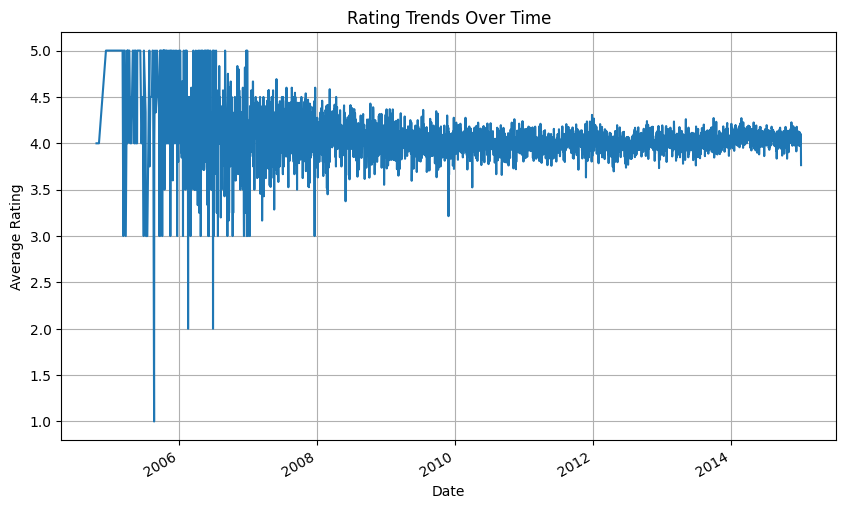

In [ ]:
# Convert 'Date' column to datetime if it's not already in datetime format
data['Date'] = pd.to_datetime(data['Date'])

plt.figure(figsize=(10, 6))
rating_trends = data.groupby('Date')['Rating'].mean()
rating_trends.plot(kind='line')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.title('Rating Trends Over Time')
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# Assuming 'df' is your DataFrame
# Separate the data based on classes
class_1 = data[data['Label'] == 1]
class_0 = data[data['Label'] == 0]

# Take 40000 samples for class '1' and keep all samples for class '1'
class_1 = class_1.sample(n=5000, random_state=42)
# Take 40000 samples for class '1' and keep all samples for class '-1'
class_0 = class_0.sample(n=3000, random_state=42)

# Concatenate the sampled data with the original data for class '-1'
balanced_data = pd.concat([class_1,class_0])

# Shuffle the balanced data
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify the class distribution after balancing
print(balanced_data['Label'].value_counts())


1    5000
0    3000
Name: Label, dtype: int64


In [ ]:
data = balanced_data.copy()

In [ ]:
data

,User_id,Product_id,Rating,Date,Review,Label
0,55492,363,5,1/13/2011,Okay where do I begin....... 1 - Meg Ryan sat ...,1
1,46928,176,5,11/17/2013,Excellent food.,1
2,52638,379,4,5/14/2010,This is a really cozy place with a nice atmosp...,1
3,47239,668,5,2/9/2014,This is one of my favorite places in the city/...,1
4,59217,380,5,8/6/2014,This place was awesome. Food was delicious and...,1
...,...,...,...,...,...,...
7995,92899,465,1,8/10/2006,"I did not like this pizza, I guess u dont know...",0
7996,104401,524,2,3/1/2013,So disappointing. Â After all the glowing revi...,0
7997,134385,711,1,6/27/2014,I I come to at least 2 to 3 times per month. I...,1
7998,65484,304,2,2/16/2014,Martha is hit and miss. It's better for brunch...,0


<ipython-input-15-a213a3c2a60f>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = data.corr()


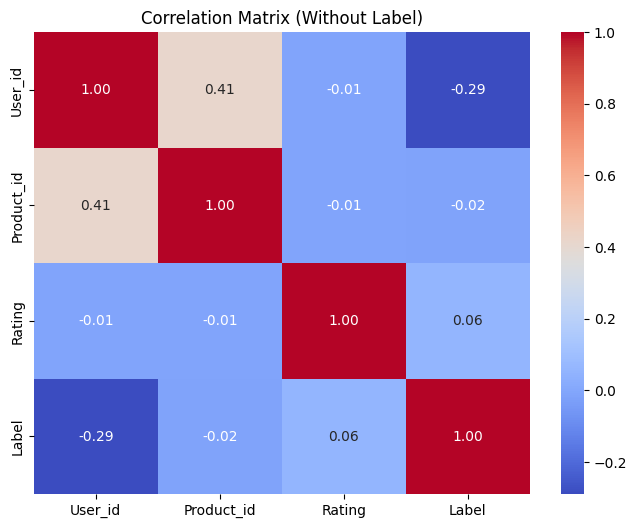

In [ ]:
# Calculate the correlation matrix without the 'Label' column
corr_matrix = data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Add title and display the plot
plt.title('Correlation Matrix (Without Label)')
plt.show()


In [ ]:
value_counts = data['Label'].value_counts()
print(value_counts)

1    5000
0    3000
Name: Label, dtype: int64


In [ ]:
data.isnull().sum()

User_id       0
Product_id    0
Rating        0
Date          0
Review        0
Label         0
dtype: int64

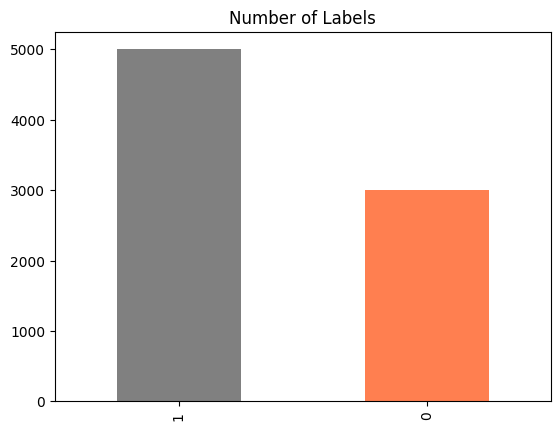

In [ ]:
import matplotlib.pyplot as plt
data["Label"].value_counts().plot(kind = "bar", color=["gray","coral"])
plt.title("Number of Labels")
plt.show()

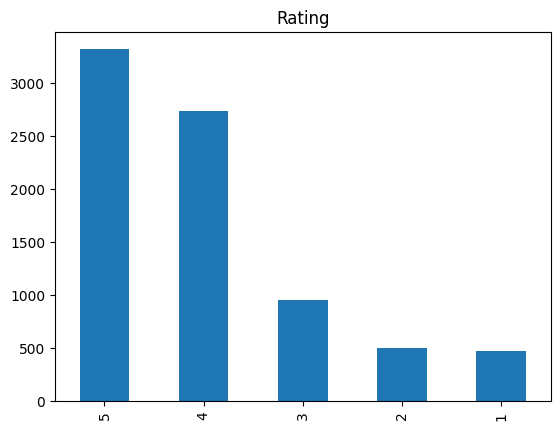

In [ ]:
data["Rating"].value_counts().plot(kind = "bar")#, color=['coral', 'c', 'limegreen', 'gold', 'plum'])
plt.title("Rating")
plt.show()

In [ ]:
x = data.iloc[:,-2]
y = data.iloc[:,-1]

In [ ]:
df = pd.concat([pd.Series(x), pd.Series(y)], axis=1)
df.head()

,Review,Label
0,Okay where do I begin....... 1 - Meg Ryan sat ...,1
1,Excellent food.,1
2,This is a really cozy place with a nice atmosp...,1
3,This is one of my favorite places in the city/...,1
4,This place was awesome. Food was delicious and...,1


# Pre_processing Reviews

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from bs4 import BeautifulSoup
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

# Download stopwords if not already downloaded
nltk.download('stopwords')

stops = set(stopwords.words('english'))  # English stopwords

stemmer = SnowballStemmer('english')  # SnowballStemmer

def review_to_words(raw_review):
    # 1. Delete HTML
    review_text = BeautifulSoup(raw_review, 'html.parser').get_text()
    # 2. Make a space
    letters_only = re.sub('[^a-zA-Z]', ' ', review_text)
    # 3. Lowercase
    words = letters_only.lower().split()
    # 4. Remove punctuation
    words = [word.translate(str.maketrans('', '', string.punctuation)) for word in words]
    # 5. Stopwords
    meaningful_words = [w for w in words if not w in stops]
    # 6. Stemming
    stemming_words = [stemmer.stem(w) for w in meaningful_words]
    # 7. Space join words
    return ' '.join(stemming_words)

# Apply review_to_words function on reviews
merge_df = x.apply(review_to_words)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
<ipython-input-21-e9ae71a27aeb>:17: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  review_text = BeautifulSoup(raw_review, 'html.parser').get_text()


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
eng_vec = CountVectorizer(max_features=5000)
bow_data = eng_vec.fit_transform(merge_df).toarray()
# pickle.dump(eng_vec, open('/content/drive/MyDrive/Fake_reviews/eng_vec.pkl', 'wb'))
features = eng_vec.get_feature_names_out()
bow_data = pd.DataFrame(bow_data, columns=features)

In [ ]:
bow_data = pd .concat([bow_data,y], axis=1)
bow_data.head()

,abc,abeill,aber,abil,abl,abroad,absenc,absent,absolut,absorb,...,zest,zhou,zing,ziti,zone,zoo,zu,zucchini,zutto,Label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


# Smote_tomek

In [ ]:
from imblearn.combine import SMOTETomek
import pandas as pd

# Create an instance of SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)

# Resample the data using SMOTE-Tomek
resampled_data = smote_tomek.fit_resample(bow_data.iloc[:, :-1], bow_data.iloc[:, -1])

# # Convert the resampled data back to a DataFrame if needed
resampled_df = pd.DataFrame(resampled_data[0])  # Features
resampled_df['Label'] = resampled_data[1]  # Target

# Check the balance of the resampled dataset
print(resampled_df['Label'].value_counts())


1    4995
0    4995
Name: Label, dtype: int64


<ipython-input-24-74f92d16d529>:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resampled_df['Label'] = resampled_data[1]  # Target


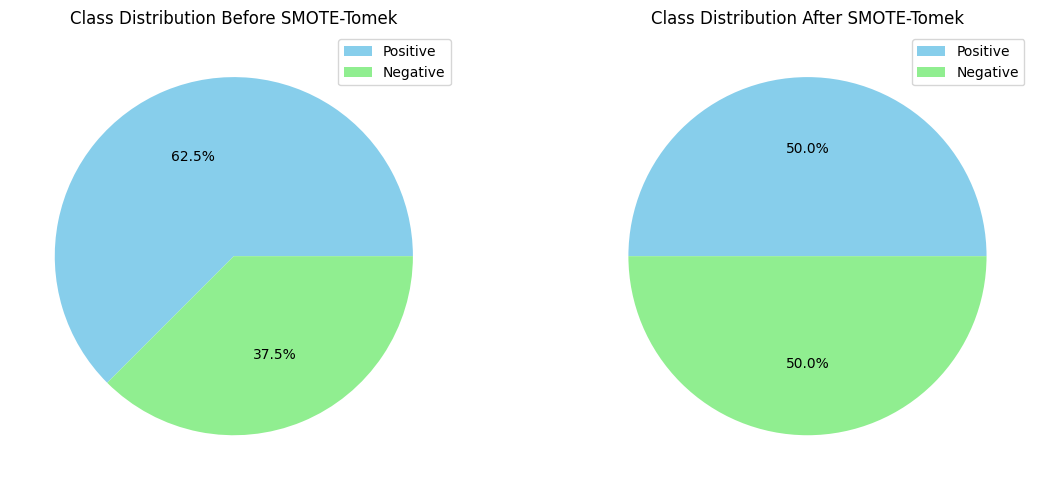

In [ ]:
# Set up subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Plot pie chart for class distribution before Random Over-Sampling
y.value_counts().plot(kind='pie', autopct='%1.1f%%', labels=None, ax=axes[0], colors=['skyblue', 'lightgreen'])
axes[0].set_title('Class Distribution Before SMOTE-Tomek')
axes[0].legend(labels=['Positive', 'Negative'], loc='best')
axes[0].set_ylabel('')

# Plot pie chart for class distribution after Random Over-Sampling
resampled_df["Label"].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=None, ax=axes[1], colors=['skyblue', 'lightgreen'])
axes[1].set_title('Class Distribution After SMOTE-Tomek')
axes[1].legend(labels=['Positive', 'Negative'], loc='best')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


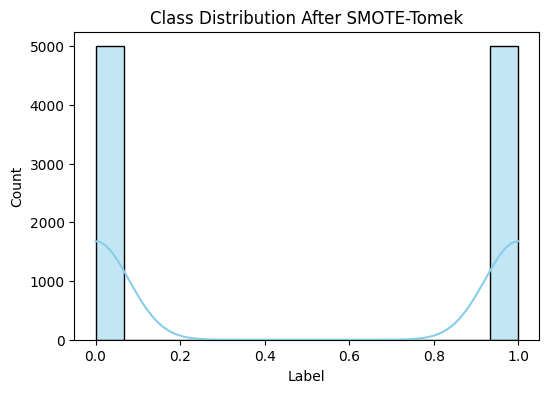

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Plotting a histogram to visualize class distribution after balancing
plt.figure(figsize=(6, 4))
sns.histplot(data=resampled_df['Label'], kde=True, color='skyblue')
plt.title('Class Distribution After SMOTE-Tomek')
plt.xlabel('Label')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
X_train,X_test,y_train,y_test = train_test_split(resampled_df.iloc[:,:-1].values,resampled_df.iloc[:,-1],test_size=0.2,random_state=42)

In [ ]:
X_train[0]

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
train_val_data = {'total data':[len(X_train),len(X_test),len(y_train),len(y_test)]}
pd.DataFrame.from_dict(train_val_data, orient='index',columns=["X_train","X_test","Y_train","Y_test"])

,X_train,X_test,Y_train,Y_test
total data,7992,1998,7992,1998


# Training using Lstm algorithm with genetic algorithm

In [ ]:
import numpy as np
import random
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
from keras.utils import to_categorical
# y_train and y_test into to_categorical
Y_train = to_categorical(y_train)
Y_test = to_categorical(y_test)

In [ ]:
num_classes = 2  # Number of classes

def create_lstm_model(params):
    model = Sequential()
    model.add(LSTM(units=params['lstm_units'], input_shape=(X_train.shape[1],1), return_sequences=True))
    model.add(Dropout(params['dropout_rate']))

    for _ in range(params['num_lstm_layers'] - 1):
        model.add(LSTM(units=params['lstm_units'], return_sequences=True))
        model.add(Dropout(params['dropout_rate']))

    model.add(LSTM(units=params['lstm_units'], return_sequences=False))
    model.add(Dense(units=128, activation='relu'))
    model.add(Dense(units=64, activation='relu'))
    model.add(Dense(units=num_classes, activation='softmax'))  # Output layer matches the number of classes

    optimizer = Adam(learning_rate=params['learning_rate'])
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model


def evaluate_fitness(params):
    model = create_lstm_model(params)

    checkpoint_filepath = '/content/drive/MyDrive/Fake_reviews/Lstm_weight.h5'
    checkpointer = ModelCheckpoint(checkpoint_filepath, verbose=1, save_best_only=True, monitor='val_accuracy')


    history = model.fit(X_train, Y_train, batch_size=params['batch_size'], epochs=params['num_epochs'],
                        verbose=1, validation_data=(X_test, Y_test), callbacks=[checkpointer])

    pickle.dump(history.history, open("/content/drive/MyDrive/Fake_reviews/history_file.pkl", "wb"))

    return history.history['val_accuracy'][-1]

def generate_random_parameters():
    params = {
        'lstm_units': random.choice([128, 256, 512]),
        'learning_rate': random.uniform(0.0001, 0.001),
        'batch_size': random.choice([32, 64, 128]),
        'num_epochs': random.randint(5, 10),  # Increase epochs for better convergence
        'num_lstm_layers': random.randint(2, 4),
        'dropout_rate': random.uniform(0.4, 0.5),
    }
    return params

def selection(population, fitness_scores, crossover_rate):
    parents = []
    for _ in range(int(crossover_rate * len(population))):
        selected = random.choices(population, weights=fitness_scores, k=2)
        parents.append(selected)
    return parents

def crossover(parents):
    offspring = []
    for parent1, parent2 in parents:
        child = {}
        for key in parent1.keys():
            child[key] = random.choice([parent1[key], parent2[key]])
        offspring.append(child)
    return offspring

def mutation(offspring, mutation_rate):
    mutated_offspring = []
    for child in offspring:
        mutated_child = {}
        for key in child.keys():
            if random.random() < mutation_rate:
                mutated_child[key] = generate_random_parameters()[key]
            else:
                mutated_child[key] = child[key]
        mutated_offspring.append(mutated_child)
    return mutated_offspring

def update_population(population, fitness_scores, offspring):
    sorted_indices = np.argsort(fitness_scores)
    for i in range(len(offspring)):
        population[sorted_indices[i]] = offspring[i]
    return population

def genetic_algorithm(population_size, generations, mutation_rate, crossover_rate):
    population = [generate_random_parameters() for _ in range(population_size)]

    for generation in range(generations):
        print(f"Generation {generation+1}")

        fitness_scores = []
        for i, params in enumerate(population):
            print(f"  Evaluating individual {i+1}/{population_size}")
            fitness_score = evaluate_fitness(params)
            fitness_scores.append(fitness_score)

        parents = selection(population, fitness_scores, crossover_rate)
        offspring = crossover(parents)
        offspring = mutation(offspring, mutation_rate)
        population = update_population(population, fitness_scores, offspring)

    best_params = max(population, key=evaluate_fitness)
    return best_params

# Set your hyperparameters
population_size = 5
generations = 2  # Increase the number of generations
mutation_rate = 0.5  # Slightly increase mutation rate
crossover_rate = 0.5  # Slightly increase crossover rate

# Run the genetic algorithm
best_parameters = genetic_algorithm(population_size, generations, mutation_rate, crossover_rate)


Generation 1
  Evaluating individual 1/5
Epoch 1/5
63/63 [==============================] - ETA: 0s - loss: 0.6707 - accuracy: 0.5841
Epoch 1: val_accuracy improved from -inf to 0.65633, saving model to /content/drive/MyDrive/Fake_reviews/Lstm_weight.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


63/63 [==============================] - 121s 2s/step - loss: 0.6707 - accuracy: 0.5841 - val_loss: 0.6345 - val_accuracy: 0.6563
Epoch 2/5
63/63 [==============================] - ETA: 0s - loss: 0.6414 - accuracy: 0.6504
Epoch 2: val_accuracy did not improve from 0.65633
63/63 [==============================] - 96s 2s/step - loss: 0.6414 - accuracy: 0.6504 - val_loss: 0.6405 - val_accuracy: 0.6203
Epoch 3/5
63/63 [==============================] - ETA: 0s - loss: 0.6798 - accuracy: 0.5687
Epoch 3: val_accuracy did not improve from 0.65633
63/63 [==============================] - 95s 2s/step - loss: 0.6798 - accuracy: 0.5687 - val_loss: 0.6859 - val_accuracy: 0.6223
Epoch 4/5
63/63 [==============================] - ETA: 0s - loss: 0.6690 - accuracy: 0.6167
Epoch 4: val_accuracy did not improve from 0.65633
63/63 [==============================] - 95s 2s/step - loss: 0.6690 - accuracy: 0.6167 - val_loss: 0.6648 - val_accuracy: 0.6033
Epoch 5/5
 2/63 [..............................] - 

KeyboardInterrupt: 

# Validaiton & Evaluation

In [ ]:
from keras.models import load_model
model_weight = load_model("/content/drive/MyDrive/Fake_reviews/Lstm_weight.h5")
prediction = model_weight.predict(X_test)

63/63 [==============================] - 61s 947ms/step


## Classification Report

In [ ]:
from sklearn.metrics import classification_report
print("Classification Report")
classes = ["Not Fake Review","Fake REview"]
print(classification_report(prediction.argmax(axis = 1),Y_test.argmax(axis = 1),target_names = classes))

Classification Report
                 precision    recall  f1-score   support

Not Fake Review       1.00      1.00      1.00       991
    Fake REview       1.00      1.00      1.00      1008

       accuracy                           1.00      1999
      macro avg       1.00      1.00      1.00      1999
   weighted avg       1.00      1.00      1.00      1999



# Confusion Matrix

Confusion matrix


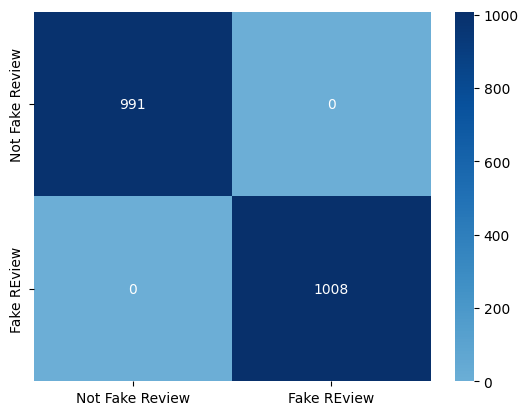

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
print("Confusion matrix")
CM_cnn = confusion_matrix(prediction.argmax(axis = 1),Y_test.argmax(axis = 1))
# drawing confusion matrix
sns.heatmap(CM_cnn, center = True , annot=True, fmt="d" ,cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.show()

# Training using CNN algorithm with genetic algorithm

In [ ]:
import random
import numpy as np
import pickle
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint


num_classes = 2

def create_cnn_model(params):
    model = Sequential()

    # Reshape input data to 3D (samples, time steps, features)
    model.add(Conv1D(filters=params['filters'], kernel_size=params['kernel_size'], activation='relu', input_shape=(X_train.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=params['filters'], kernel_size=params['kernel_size'], activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=params['filters'], kernel_size=params['kernel_size'], activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(params['dense_units'], activation='relu'))
    model.add(Dropout(params['dropout_rate']))
    model.add(Dense(num_classes, activation='softmax'))

    optimizer = Adam(learning_rate=params['learning_rate'])
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

def evaluate_fitness(params):
    model = create_cnn_model(params)

    checkpoint_filepath = '/content/drive/MyDrive/Fake_reviews/Cnn_weight.h5'
    checkpointer = ModelCheckpoint(checkpoint_filepath, verbose=1, save_best_only=True, monitor='val_accuracy')

    history = model.fit(X_train, Y_train, batch_size=params['batch_size'], epochs=params['num_epochs'],
                        verbose=1, validation_data=(X_test, Y_test), callbacks=[checkpointer])

    pickle.dump(history.history, open("/content/drive/MyDrive/Fake_reviews/Cnn_history_file.pkl", "wb"))

    return history.history['val_accuracy'][-1]

def generate_random_parameters():
    params = {
        'filters': random.choice([16, 32, 64]),
        'kernel_size': random.choice([(3), (5)]),
        'dense_units': random.choice([64, 128, 256]),
        'learning_rate': random.uniform(0.0001, 0.001),
        'batch_size': random.choice([32, 64, 128]),
        'num_epochs': random.randint(5, 10),
        'num_conv_layers': random.randint(2, 4),
        'dropout_rate': random.uniform(0.4, 0.5),
    }
    return params


def selection(population, fitness_scores, crossover_rate):
    parents = []
    for _ in range(int(crossover_rate * len(population))):
        selected = random.choices(population, weights=fitness_scores, k=2)
        parents.append(selected)
    return parents

def crossover(parents):
    offspring = []
    for parent1, parent2 in parents:
        child = {}
        for key in parent1.keys():
            child[key] = random.choice([parent1[key], parent2[key]])
        offspring.append(child)
    return offspring

def mutation(offspring, mutation_rate):
    mutated_offspring = []
    for child in offspring:
        mutated_child = {}
        for key in child.keys():
            if random.random() < mutation_rate:
                mutated_child[key] = generate_random_parameters()[key]
            else:
                mutated_child[key] = child[key]
        mutated_offspring.append(mutated_child)
    return mutated_offspring

def update_population(population, fitness_scores, offspring):
    sorted_indices = np.argsort(fitness_scores)
    for i in range(len(offspring)):
        population[sorted_indices[i]] = offspring[i]
    return population

def genetic_algorithm_cnn(population_size, generations, mutation_rate, crossover_rate):
    population = [generate_random_parameters() for _ in range(population_size)]

    for generation in range(generations):
        print(f"Generation {generation+1}")

        fitness_scores = []
        for i, params in enumerate(population):
            print(f"  Evaluating individual {i+1}/{population_size}")
            fitness_score = evaluate_fitness(params)
            fitness_scores.append(fitness_score)

        parents = selection(population, fitness_scores, crossover_rate)
        offspring = crossover(parents)
        offspring = mutation(offspring, mutation_rate)
        population = update_population(population, fitness_scores, offspring)

    best_params = max(population, key=evaluate_fitness)
    return best_params

# Set your hyperparameters
population_size = 5
generations = 2  # Increase the number of generations
mutation_rate = 0.5  # Slightly increase mutation rate
crossover_rate = 0.5  # Slightly increase crossover rate

# Run the genetic algorithm
best_parameters = genetic_algorithm_cnn(population_size, generations, mutation_rate, crossover_rate)


Generation 1
  Evaluating individual 1/5
Epoch 1/9
125/125 [==============================] - ETA: 0s - loss: 0.6349 - accuracy: 0.6637
Epoch 1: val_accuracy improved from -inf to 0.72873, saving model to /content/drive/MyDrive/Fake_reviews/Cnn_weight.h5
125/125 [==============================] - 46s 341ms/step - loss: 0.6349 - accuracy: 0.6637 - val_loss: 0.5949 - val_accuracy: 0.7287
Epoch 2/9


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


125/125 [==============================] - ETA: 0s - loss: 0.5765 - accuracy: 0.7305
Epoch 2: val_accuracy improved from 0.72873 to 0.73073, saving model to /content/drive/MyDrive/Fake_reviews/Cnn_weight.h5
125/125 [==============================] - 38s 306ms/step - loss: 0.5765 - accuracy: 0.7305 - val_loss: 0.5675 - val_accuracy: 0.7307
Epoch 3/9
125/125 [==============================] - ETA: 0s - loss: 0.5367 - accuracy: 0.7460
Epoch 3: val_accuracy improved from 0.73073 to 0.73323, saving model to /content/drive/MyDrive/Fake_reviews/Cnn_weight.h5
125/125 [==============================] - 37s 299ms/step - loss: 0.5367 - accuracy: 0.7460 - val_loss: 0.5551 - val_accuracy: 0.7332
Epoch 4/9
125/125 [==============================] - ETA: 0s - loss: 0.5060 - accuracy: 0.7628
Epoch 4: val_accuracy improved from 0.73323 to 0.73473, saving model to /content/drive/MyDrive/Fake_reviews/Cnn_weight.h5
125/125 [==============================] - 35s 279ms/step - loss: 0.5060 - accuracy: 0.7628

KeyboardInterrupt: 

# Validaiton & Evaluation

In [ ]:
from keras.models import load_model
model_weight = load_model("/content/drive/MyDrive/Fake_reviews/Cnn_weight.h5")
cnn_prediction = model_weight.predict(X_test)

63/63 [==============================] - 6s 93ms/step


## Classification Rport

In [ ]:
from sklearn.metrics import classification_report
print("Classification Report")
classes = ["Not Fake Review","Fake REview"]
print(classification_report(cnn_prediction.argmax(axis = 1),Y_test.argmax(axis = 1),target_names = classes))

Classification Report
                 precision    recall  f1-score   support

Not Fake Review       0.68      0.79      0.73       889
    Fake REview       0.81      0.71      0.75      1109

       accuracy                           0.74      1998
      macro avg       0.74      0.75      0.74      1998
   weighted avg       0.75      0.74      0.74      1998



# Confusion Matrix

Confusion matrix


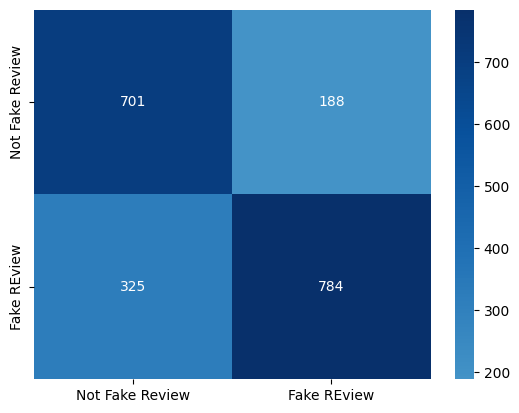

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
print("Confusion matrix")
CM_cnn = confusion_matrix(cnn_prediction.argmax(axis = 1),Y_test.argmax(axis = 1))
# drawing confusion matrix
sns.heatmap(CM_cnn, center = True , annot=True, fmt="d" ,cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.show()

# Training using DNN algorithm with genetic algorithm

In [ ]:
import random
import numpy as np
import pickle
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint

num_classes = 2  # Number of classes

def create_dnn_model(params):
    model = Sequential()

    # Input layer
    model.add(Dense(units=params['dense_units'], activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dropout(params['dropout_rate']))

    # Hidden layers
    for _ in range(params['num_dense_layers']):
        model.add(Dense(units=params['dense_units'], activation='relu'))
        model.add(Dropout(params['dropout_rate']))

    # Output layer
    model.add(Dense(units=num_classes, activation='softmax'))

    # Compile model
    optimizer = Adam(learning_rate=params['learning_rate'])
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

def evaluate_fitness(params):
    model = create_dnn_model(params)

    checkpoint_filepath = '/content/drive/MyDrive/Fake_reviews/DNN_weight.h5'
    checkpointer = ModelCheckpoint(checkpoint_filepath, verbose=1, save_best_only=True, monitor='val_accuracy')

    history = model.fit(X_train, Y_train, batch_size=params['batch_size'], epochs=params['num_epochs'],
                        verbose=1, validation_data=(X_test, Y_test), callbacks=[checkpointer])

    pickle.dump(history.history, open("/content/drive/MyDrive/Fake_reviews/DNN_history_file.pkl", "wb"))

    return history.history['val_accuracy'][-1]

def generate_random_parameters():
    params = {
        'dense_units': random.choice([64, 128, 256]),
        'learning_rate': random.uniform(0.0001, 0.001),
        'batch_size': random.choice([32, 64, 128]),
        'num_epochs': random.randint(5, 10),  # Increase epochs for better convergence
        'num_dense_layers': random.randint(2, 4),  # Number of dense layers
        'dropout_rate': random.uniform(0.4, 0.5),
    }
    return params

# Rest of the functions (selection, crossover, mutation, update_population, genetic_algorithm) remain the same.

# Genetic algorithm function for DNN
def genetic_algorithm_dnn(population_size, generations, mutation_rate, crossover_rate):
    population = [generate_random_parameters() for _ in range(population_size)]

    for generation in range(generations):
        print(f"Generation {generation+1}")

        fitness_scores = []
        for i, params in enumerate(population):
            print(f"  Evaluating individual {i+1}/{population_size}")
            fitness_score = evaluate_fitness(params)
            fitness_scores.append(fitness_score)

        parents = selection(population, fitness_scores, crossover_rate)
        offspring = crossover(parents)
        offspring = mutation(offspring, mutation_rate)
        population = update_population(population, fitness_scores, offspring)

    best_params = max(population, key=evaluate_fitness)
    return best_params

# Set your hyperparameters
population_size = 5
generations = 2  # Increase the number of generations
mutation_rate = 0.5  # Slightly increase mutation rate
crossover_rate = 0.5  # Slightly increase crossover rate

# Run the genetic algorithm for DNN
best_parameters_dnn = genetic_algorithm_dnn(population_size, generations, mutation_rate, crossover_rate)


Generation 1
  Evaluating individual 1/5
Epoch 1/5
62/63 [============================>.] - ETA: 0s - loss: 0.6448 - accuracy: 0.6360
Epoch 1: val_accuracy improved from -inf to 0.71872, saving model to /content/drive/MyDrive/Fake_reviews/DNN_weight.h5
63/63 [==============================] - 4s 37ms/step - loss: 0.6445 - accuracy: 0.6364 - val_loss: 0.5899 - val_accuracy: 0.7187
Epoch 2/5
 1/63 [..............................] - ETA: 2s - loss: 0.6164 - accuracy: 0.6562

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


62/63 [============================>.] - ETA: 0s - loss: 0.5691 - accuracy: 0.7185
Epoch 2: val_accuracy improved from 0.71872 to 0.73123, saving model to /content/drive/MyDrive/Fake_reviews/DNN_weight.h5
63/63 [==============================] - 2s 37ms/step - loss: 0.5685 - accuracy: 0.7187 - val_loss: 0.5417 - val_accuracy: 0.7312
Epoch 3/5
62/63 [============================>.] - ETA: 0s - loss: 0.4914 - accuracy: 0.7656
Epoch 3: val_accuracy improved from 0.73123 to 0.74324, saving model to /content/drive/MyDrive/Fake_reviews/DNN_weight.h5
63/63 [==============================] - 1s 23ms/step - loss: 0.4914 - accuracy: 0.7656 - val_loss: 0.5340 - val_accuracy: 0.7432
Epoch 4/5
61/63 [============================>.] - ETA: 0s - loss: 0.4056 - accuracy: 0.8181
Epoch 4: val_accuracy did not improve from 0.74324
63/63 [==============================] - 1s 21ms/step - loss: 0.4056 - accuracy: 0.8184 - val_loss: 0.5664 - val_accuracy: 0.7402
Epoch 5/5
60/63 [===========================>.

KeyboardInterrupt: 

# Validaiton & Evaluation

In [ ]:
from keras.models import load_model
model_weight = load_model("/content/drive/MyDrive/Fake_reviews/DNN_weight.h5")
dnn_prediction = model_weight.predict(X_test)

63/63 [==============================] - 0s 4ms/step


## Classification Rport

In [ ]:
from sklearn.metrics import classification_report
print("Classification Report")
classes = ["Not Fake Review","Fake REview"]
print(classification_report(dnn_prediction.argmax(axis = 1),Y_test.argmax(axis = 1),target_names = classes))

Classification Report
                 precision    recall  f1-score   support

Not Fake Review       0.70      0.78      0.74       926
    Fake REview       0.79      0.71      0.75      1072

       accuracy                           0.74      1998
      macro avg       0.74      0.75      0.74      1998
   weighted avg       0.75      0.74      0.74      1998



# Confusion Matrix

Confusion matrix


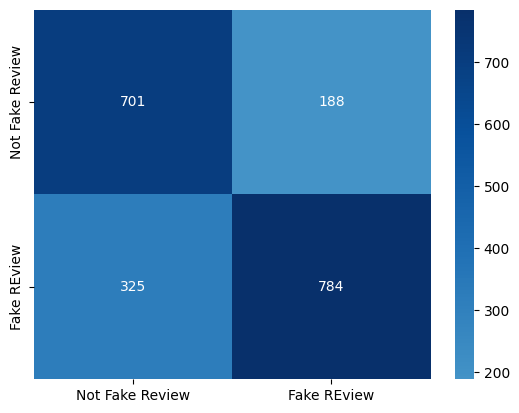

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
print("Confusion matrix")
CM_cnn = confusion_matrix(cnn_prediction.argmax(axis = 1),Y_test.argmax(axis = 1))
# drawing confusion matrix
sns.heatmap(CM_cnn, center = True , annot=True, fmt="d" ,cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.show()

# Prediction

In [ ]:
from bs4 import BeautifulSoup
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pickle
import pandas as pd
from keras.models import load_model
import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv('/content/drive/MyDrive/Fake_reviews/df.csv')
test_data = df.sample(n=1).values[0]

nltk.download('stopwords')
stops = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

def review_to_words(raw_review):
    review_text = BeautifulSoup(raw_review, 'html.parser').get_text()
    letters_only = re.sub('[^a-zA-Z]', ' ', review_text)
    words = letters_only.lower().split()
    words = [word.translate(str.maketrans('', '', string.punctuation)) for word in words]
    meaningful_words = [w for w in words if not w in stops]
    stemming_words = [stemmer.stem(w) for w in meaningful_words]
    return ' '.join(stemming_words)

eng_vec = CountVectorizer(max_features=5000)
x = test_data[0]
data = review_to_words(x)
print(data)

eng_vec = pickle.load(open('/content/drive/MyDrive/Fake_reviews/eng_vec.pkl', 'rb'))
data = eng_vec.transform([data]).toarray()

model = load_model('/content/drive/MyDrive/Fake_reviews/Lstm_weight.h5')
prediction = model.predict(data)
model_pred = prediction.argmax(axis = 1)[0]

if model_pred==0:
    print('The Model Prediction is Not Fake')
else:
    print('The Model Prediction is Fake')

In [ ]:
test_data[0]

'Dinner was great, not too hard to get a table even without a reservation. The menu could be expanded a little bit but the available dishes were fantastic. The appetizers are great in terms of diversity and the cured meats were not too salty but very diversified in taste. Pizza is best bet, but the different pasta dishes are nicely sized given their price and similar competition.'

# Backend Integrate with FrontEnd using Flask and Ngrok

In [ ]:
!curl -s https://ngrok-agent.s3.amazonaws.com/ngrok.asc | sudo tee /etc/apt/trusted.gpg.d/ngrok.asc >/dev/null && echo "deb https://ngrok-agent.s3.amazonaws.com buster main" | sudo tee /etc/apt/sources.list.d/ngrok.list && sudo apt update && sudo apt install ngrok

deb https://ngrok-agent.s3.amazonaws.com buster main
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [110 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://ngrok-agent.s3.amazonaws.com buster InRelease [20.3 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [119 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [737 kB]
Hit:8 https://ppa.launchpadcontent.net/c2d4u.team/c2d4u4.0+/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,079 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [109 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ub

In [ ]:
!pip install pyngrok
!pip install flask-ngrok
!ngrok authtoken 24jMmkCh5Tr4hOZ9Dpg69QtTDSH_3n21SSxtBHr1F9QckcBzi

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from bs4 import BeautifulSoup
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from flask_ngrok import run_with_ngrok
from flask import Flask
from flask import Flask, app,request
import json
import sys
from flask import jsonify
from pyngrok import ngrok
import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")


app = Flask(__name__)
# cors = CORS(app)
run_with_ngrok(app)   #starts ngrok when the app is run
@app.route('/fake_review', methods=['GET','POST'])
# @cross_origin()
def login():
    result = input(request.values.get('uri'))
    return result
def input(uri):
    print("[INFO] loading model...")
    input_data = uri.split(',')

    print(input_data)

    nltk.download('stopwords')
    stops = set(stopwords.words('english'))  # English stopwords
    stemmer = SnowballStemmer('english')  # SnowballStemmer
    eng_vec = CountVectorizer(max_features=5000)
    def review_to_words(raw_review):
        review_text = BeautifulSoup(raw_review, 'html.parser').get_text()
        letters_only = re.sub('[^a-zA-Z]', ' ', review_text)
        words = letters_only.lower().split()
        words = [word.translate(str.maketrans('', '', string.punctuation)) for word in words]
        meaningful_words = [w for w in words if not w in stops]
        stemming_words = [stemmer.stem(w) for w in meaningful_words]
        return ' '.join(stemming_words)

    data = review_to_words(input_data[0])
    print(data)

    eng_vec = pickle.load(open('/content/drive/MyDrive/Fake_reviews/eng_vec.pkl', 'rb'))
    data = eng_vec.transform([data]).toarray()

    model = load_model('/content/drive/MyDrive/Fake_reviews/Lstm_weight.h5')
    prediction = model.predict(np.array(data).reshape(1,-1))
    model_pred = prediction.argmax(axis = 1)
    final_output = {0:'Fake', 1:'Not Fake'}
    return {"data": str(final_output[model_pred[0]])}


if __name__ == '__main__':
    port = "5000"
    # Open a ngrok tunnel to the HTTP server
    public_url = ngrok.connect(port).public_url
    # print(f"* ngrok tunnel \{public_url}\ -> \http://127.0.0.1:{port}\")
    print(f"Running on: {public_url}")

    app.run()

Running on: https://7256-35-238-246-190.ngrok-free.app
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


 * Running on http://7256-35-238-246-190.ngrok-free.app
 * Traffic stats available on http://127.0.0.1:4040
[INFO] loading model...
["Don't go here if you are gluten intolerant! The staff was very clear with us that they cannot accommodate this need."]
go gluten intoler staff clear us cannot accommod need


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


1/1 [==============================] - 2s 2s/step


INFO:werkzeug:127.0.0.1 - - [18/Mar/2024 06:35:40] "POST /fake_review HTTP/1.1" 200 -


[INFO] loading model...
["Don't go here if you are gluten intolerant! The staff was very clear with us that they cannot accommodate this need."]
go gluten intoler staff clear us cannot accommod need


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


1/1 [==============================] - 2s 2s/step


INFO:werkzeug:127.0.0.1 - - [18/Mar/2024 06:36:00] "POST /fake_review HTTP/1.1" 200 -


[INFO] loading model...
['Classic. Very very good. Not pretentious. Ã‚ Would recommend to anyone. Ã‚ Try the peach house frozen drink and the Tiramisu. Ã‚ Both are very nice.']
classic good pretenti would recommend anyon tri peach hous frozen drink tiramisu nice


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


1/1 [==============================] - 2s 2s/step


INFO:werkzeug:127.0.0.1 - - [18/Mar/2024 06:36:32] "POST /fake_review HTTP/1.1" 200 -


[INFO] loading model...
["Don't go here if you are gluten intolerant! The staff was very clear with us that they cannot accommodate this need."]
go gluten intoler staff clear us cannot accommod need


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


1/1 [==============================] - 2s 2s/step


INFO:werkzeug:127.0.0.1 - - [18/Mar/2024 06:37:17] "POST /fake_review HTTP/1.1" 200 -
